# Data Modeling for Analytics (Star Schemas)

There are two main types of databases in the world:
1. **OLTP (Online Transaction Processing)**: These are the highly normalized databases we built in previous lessons. They are designed to process millions of fast, tiny inserts and updates (like a user clicking "Buy"). 
2. **OLAP (Online Analytical Processing)**: These are **Data Warehouses**. They are designed to process slow, massive `SELECT` queries (like "Calculate the total revenue for all stores over the last 5 years"). 

To make analytical queries fast and easy to write, Data Engineers transform the messy, highly-normalized OLTP data into a specific structure called a **Star Schema**. 

Let's use Python to visualize what a Star Schema looks like before we build one!

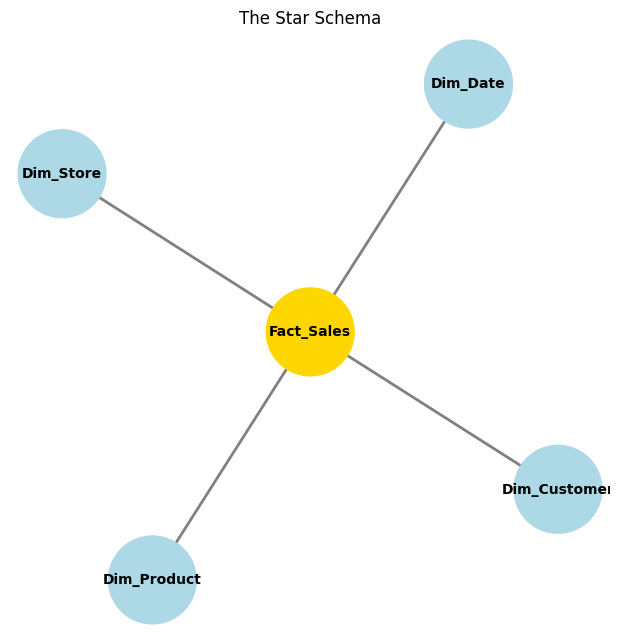

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph to visualize a Star Schema
G = nx.Graph()

# Add the central Fact Table
fact_node = "Fact_Sales"
G.add_node(fact_node)

# Add the surrounding Dimension Tables
dimensions = ["Dim_Customer", "Dim_Product", "Dim_Store", "Dim_Date"]
for dim in dimensions:
    G.add_node(dim)
    G.add_edge(fact_node, dim) # Connect dimensions to the center

# Define colors (Gold for Fact, Light Blue for Dimensions)
colors = ['gold' if node == fact_node else 'lightblue' for node in G.nodes()]

# Plot the Star Schema
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=4000, 
        font_weight='bold', font_size=10, edge_color='gray', width=2)

plt.title("The Star Schema")
plt.show()

# 1. Fact Tables (The "Numbers")
The center of the star is the **Fact Table**. A fact table records a specific event or measurement that happens in your business. 

* **Traits**: It contains massive amounts of rows, but very few columns.
* **Contents**: It contains **Metrics** (numbers you can add up, like `amount_paid` or `quantity_sold`) and **Foreign Keys** pointing to the dimension tables.
* **Examples**: A sale, a website click, an ATM withdrawal.


# 2. Dimension Tables (The "Context")
The points of the star are the **Dimension Tables**. They provide the descriptive context surrounding the fact. 

* **Traits**: They contain fewer rows, but many, many columns. They are highly "denormalized" (we intentionally allow duplicate data here to make querying easier).
* **Contents**: Descriptive text attributes (names, categories, locations).
* **Examples**: `Dim_Customer` (contains name, email, age, city, state), `Dim_Date` (contains day, month, year, quarter, is_holiday).

# 3. Building a Star Schema in SQL
Let's build a mini Data Warehouse in our SQLite sandbox.

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# 1. Create the Dimension Tables (The Context)
cursor.executescript("""
CREATE TABLE Dim_Product (
    product_key INTEGER PRIMARY KEY, -- The "Surrogate" Key
    product_name TEXT,
    category TEXT,
    supplier_name TEXT
);

CREATE TABLE Dim_Date (
    date_key INTEGER PRIMARY KEY, -- Usually formatted as YYYYMMDD
    full_date DATE,
    month_name TEXT,
    year INTEGER,
    quarter TEXT
);

-- 2. Create the Fact Table (The Metrics)
CREATE TABLE Fact_Sales (
    sale_id INTEGER PRIMARY KEY,
    product_key INTEGER, -- Points to Dim_Product
    date_key INTEGER,    -- Points to Dim_Date
    quantity_sold INTEGER,
    total_revenue DECIMAL(10, 2)
);

-- 3. Insert Dummy Data
INSERT INTO Dim_Product VALUES 
(1, 'Laptop Pro', 'Electronics', 'TechCorp'),
(2, 'Coffee Mug', 'Home', 'MugMaker');

INSERT INTO Dim_Date VALUES 
(20231001, '2023-10-01', 'October', 2023, 'Q4'),
(20231002, '2023-10-02', 'October', 2023, 'Q4');

INSERT INTO Fact_Sales VALUES 
(1001, 1, 20231001, 2, 2400.00),
(1002, 2, 20231001, 5, 50.00),
(1003, 1, 20231002, 1, 1200.00);
""")

print("✅ Star Schema Data Warehouse Built!")

✅ Star Schema Data Warehouse Built!


# 4. Why Use a Star Schema? (Query Simplicity)
If we kept our data highly normalized (like in Lesson 01), a Data Scientist might have to `JOIN` 10 different tables together just to find the total revenue by category. 

With a Star Schema, the query is incredibly simple. You just join the Fact table to the specific Dimension table you care about. 

In [3]:
# Business Question: What is our total revenue by product category for Q4 of 2023?
query_analytics = """
SELECT 
    p.category, 
    d.quarter,
    SUM(f.total_revenue) as total_revenue
FROM Fact_Sales f
JOIN Dim_Product p ON f.product_key = p.product_key
JOIN Dim_Date d ON f.date_key = d.date_key
WHERE d.year = 2023 AND d.quarter = 'Q4'
GROUP BY p.category, d.quarter;
"""

print("--- Data Warehouse Analytics Report ---")
display(pd.read_sql_query(query_analytics, conn))

conn.close()

--- Data Warehouse Analytics Report ---


,category,quarter,total_revenue
0,Electronics,Q4,3600
1,Home,Q4,50


## Real-World Use Case or Analogy:
Think of a Star Schema like a **Journalist reporting on a story**:

* **The Fact Table (The Event)**: This is the core action. *"A car crash occurred, resulting in $5,000 in damages."* That is the metric. But by itself, it's not very helpful.
* **The Dimension Tables (The 5 W's)**: To understand the event, the journalist surrounds the fact with context:
    * **Who** (`Dim_Driver`): John Doe, 35 years old, licensed in NY.
    * **What** (`Dim_Vehicle`): 2018 Honda Civic, Blue.
    * **Where** (`Dim_Location`): Main Street & 5th Avenue, Intersection, Wet conditions.
    * **When** (`Dim_Date`): Friday, October 13th, 2023, 8:45 PM, Q4.
* **The Analytics**: Because all this context is pre-organized into clean dimensions, the City Planner (Data Scientist) can easily run a report answering: *"How many dollars in damages occurred at Intersections on Fridays during wet conditions?"*

---